In [32]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path


In [160]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*0.WAV'))
all_sync_wav_files = list(experiment_folder.glob('STF_*/2026*_SYNC.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*0.CSV'))
all_wav_files, all_sync_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_003000.WAV'),


In [161]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [162]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [163]:
valid_wav_files = dict.fromkeys(SD_CARD_TO_AUDIOMOTH_NUM, [])
for wav_file in all_wav_files:
    wav_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    sd_card_name = wav_file.parts[-2]
    valid_wav_files[sd_card_name] += [wav_file]
valid_wav_files

{'STF_026': [PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_003

In [164]:
valid_sync_csv_files = dict.fromkeys(SD_CARD_TO_AUDIOMOTH_NUM, [])
for csv_file in all_csv_files:
    csv_file_dt = dt.datetime.strptime(csv_file.name, '%Y%m%d_%H%M%S.CSV')
    sd_card_name = csv_file.parts[-2]
    valid_sync_csv_files[sd_card_name] += [csv_file]
valid_sync_csv_files

{'STF_026': [PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_003

In [165]:
valid_sync_csv_files['STF_027'][1], valid_wav_files['STF_027'][0]

(PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'))

In [166]:
# No Dask dependency is needed for these file lists.

In [167]:
valid_sync_csv_files = {}

for sd_card_name in SD_CARD_TO_AUDIOMOTH_NUM:
    valid_sync_csv_files[sd_card_name] = []

for csv_file in all_csv_files:
    sd_card_name = csv_file.parts[-2]
    valid_sync_csv_files[sd_card_name].append(csv_file)

In [168]:
NOMINAL_SAMPLE_RATE = 48000
SECONDS_PER_30_MINUTES = 30 * 60

In [169]:
clock_drift_rows = []
clock_drift_timeseries = {}

csv_data = pd.read_csv(Path('/Volumes/STF_106/20260728_212940.CSV'))

valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
csv_data = csv_data.loc[valid_rows].copy()

csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"])
csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

# The first valid row represents the first one-second PPS interval.
csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE

gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
final_clock_error_samples = csv_data["clock_error_samples"].iloc[-1]
final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds

clock_drift_rows.append({
    "file": csv_file.name,
    "gps_duration_seconds": gps_duration_seconds,
    "observed_sample_rate": observed_sample_rate,
    "final_clock_error_samples": final_clock_error_samples,
    "final_clock_error_seconds": final_clock_error_seconds
    })

clock_drift_timeseries[csv_file.name] = csv_data

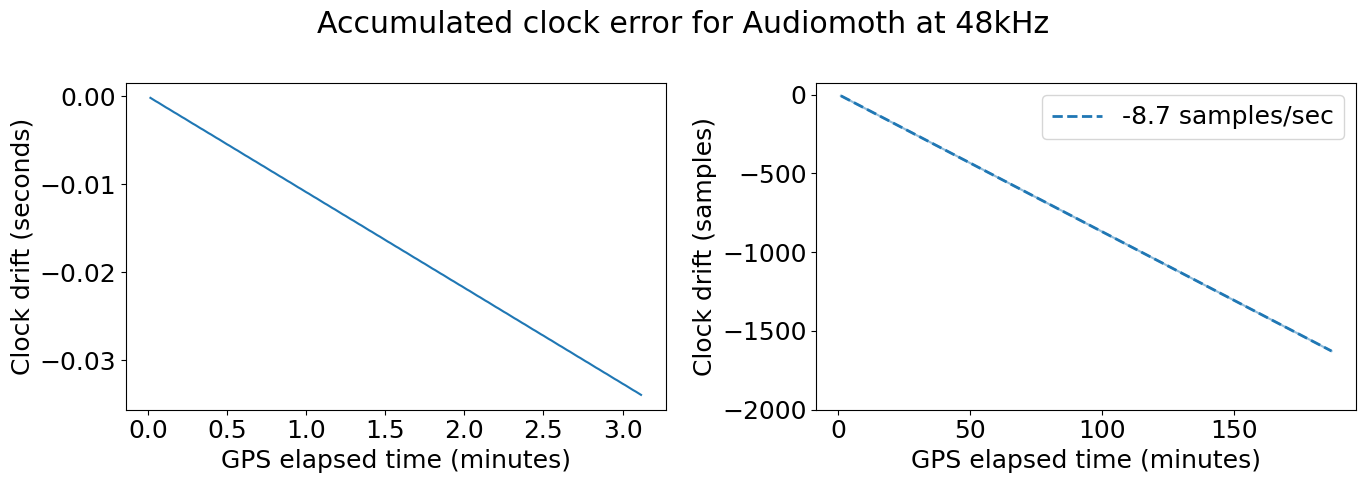

In [170]:
fig, ax_all = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams.update({'font.size': 18})

fig.suptitle(f"Accumulated clock error for Audiomoth at 48kHz")

ax = ax_all[0]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = (csv_data["gps_elapsed_seconds"] / 60)
    ax.plot(elapsed_minutes, csv_data["clock_error_seconds"], label=file_name)

ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (seconds)")

ax = ax_all[1]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = csv_data["gps_elapsed_seconds"] / 60
    elapsed_secs = elapsed_minutes * 60
    clock_error_samples = csv_data["clock_error_samples"]

    valid_values = elapsed_secs.notna() & clock_error_samples.notna()
    regression_x = elapsed_secs.loc[valid_values].to_numpy()
    regression_y = clock_error_samples.loc[valid_values].to_numpy()

    slope, intercept = np.polyfit(regression_x, regression_y, deg=1)
    regression_y_predicted = slope * regression_x + intercept

    line, = ax.plot(regression_x, regression_y, alpha=0.5)
    ax.plot(
        regression_x,
        regression_y_predicted,
        linestyle="--",
        linewidth=2,
        color=line.get_color(),
        label=f"{slope:.1f} samples/sec",
    )

ax.set_yticks(np.arange(-2000, 100, 500))
ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (samples)")
ax.legend(fontsize=18)

fig.tight_layout()
plt.show()

In [171]:
csv_data = pd.read_csv(valid_sync_csv_files["STF_027"][1])

valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
csv_data = csv_data.loc[valid_rows].copy()

csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"])
csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

# The first valid row represents the first one-second PPS interval.
csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE
csv_data

,PPS_NUMBER,AUDIOMOTH_TIME,SAMPLES,TOTAL_SAMPLES,TIMER_COUNT,BUFFERS_FILLED,BUFFERS_WRITTEN,LAST_RMC_AUDIOMOTH_TIME,LAST_RMC_GPS_TIME,STATUS,...,LAT_DIR,LONG_DEG,LONG_MIN,LONG_DIR,gps_time,gps_interval_seconds,gps_elapsed_seconds,expected_total_samples,clock_error_samples,clock_error_seconds
1,1,2026-06-04T21:00:00.999,191965,191965,244,11,11,2026-06-04T21:00:00.363,2026-06-04T21:00:00.000,A,...,N,122.0,17.6912,W,2026-06-04 21:00:00,1.0,1.0,48000.0,143965.0,2.999271
2,2,2026-06-04T21:00:01.999,191964,383929,111,23,23,2026-06-04T21:00:01.572,2026-06-04T21:00:01.000,A,...,N,122.0,17.6912,W,2026-06-04 21:00:01,1.0,2.0,96000.0,287929.0,5.998521
3,3,2026-06-04T21:00:02.999,191964,575893,227,35,35,2026-06-04T21:00:02.361,2026-06-04T21:00:02.000,A,...,N,122.0,17.6912,W,2026-06-04 21:00:02,1.0,3.0,144000.0,431893.0,8.997771
4,4,2026-06-04T21:00:03.999,191965,767858,94,46,46,2026-06-04T21:00:03.363,2026-06-04T21:00:03.000,A,...,N,122.0,17.6912,W,2026-06-04 21:00:03,1.0,4.0,192000.0,575858.0,11.997042
5,5,2026-06-04T21:00:04.999,191964,959822,211,58,58,2026-06-04T21:00:04.362,2026-06-04T21:00:04.000,A,...,N,122.0,17.6912,W,2026-06-04 21:00:04,1.0,5.0,240000.0,719822.0,14.996292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,1639,2026-06-04T21:27:55.966,191964,321732442,228,19636,19636,2026-06-04T21:27:55.333,2026-06-04T21:27:55.000,A,...,N,122.0,17.6915,W,2026-06-04 21:27:55,1.0,1676.0,80448000.0,241284442.0,5026.759208
1640,1640,2026-06-04T21:27:56.966,191965,321924407,85,19648,19648,2026-06-04T21:27:56.550,2026-06-04T21:27:56.000,A,...,N,122.0,17.6915,W,2026-06-04 21:27:56,1.0,1677.0,80496000.0,241428407.0,5029.758479
1641,1641,2026-06-04T21:27:57.966,191964,322116371,192,19660,19660,2026-06-04T21:27:57.332,2026-06-04T21:27:57.000,A,...,N,122.0,17.6915,W,2026-06-04 21:27:57,1.0,1678.0,80544000.0,241572371.0,5032.757729
1642,1642,2026-06-04T21:27:58.966,191965,322308336,49,19672,19672,2026-06-04T21:27:58.332,2026-06-04T21:27:58.000,A,...,N,122.0,17.6915,W,2026-06-04 21:27:58,1.0,1679.0,80592000.0,241716336.0,5035.757000


In [172]:
nominal_sample_rate = 192000
actual_sample_rate = 191964.5
duration_seconds = 60 * 60

expected_clock_error_seconds = duration_seconds * ((actual_sample_rate / nominal_sample_rate) - 1)

print(expected_clock_error_seconds)

-0.665625000000114


In [173]:
gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds
clock_error_per_30_minutes = final_clock_error_seconds / gps_duration_seconds * SECONDS_PER_30_MINUTES

In [176]:
NOMINAL_SAMPLE_RATE = 192000
SECONDS_PER_30_MINUTES = 30 * 60

/var/folders/qj/4txkrxcn2ld7mby9_6n6npnr0000gn/T/ipykernel_70452/2471314349.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


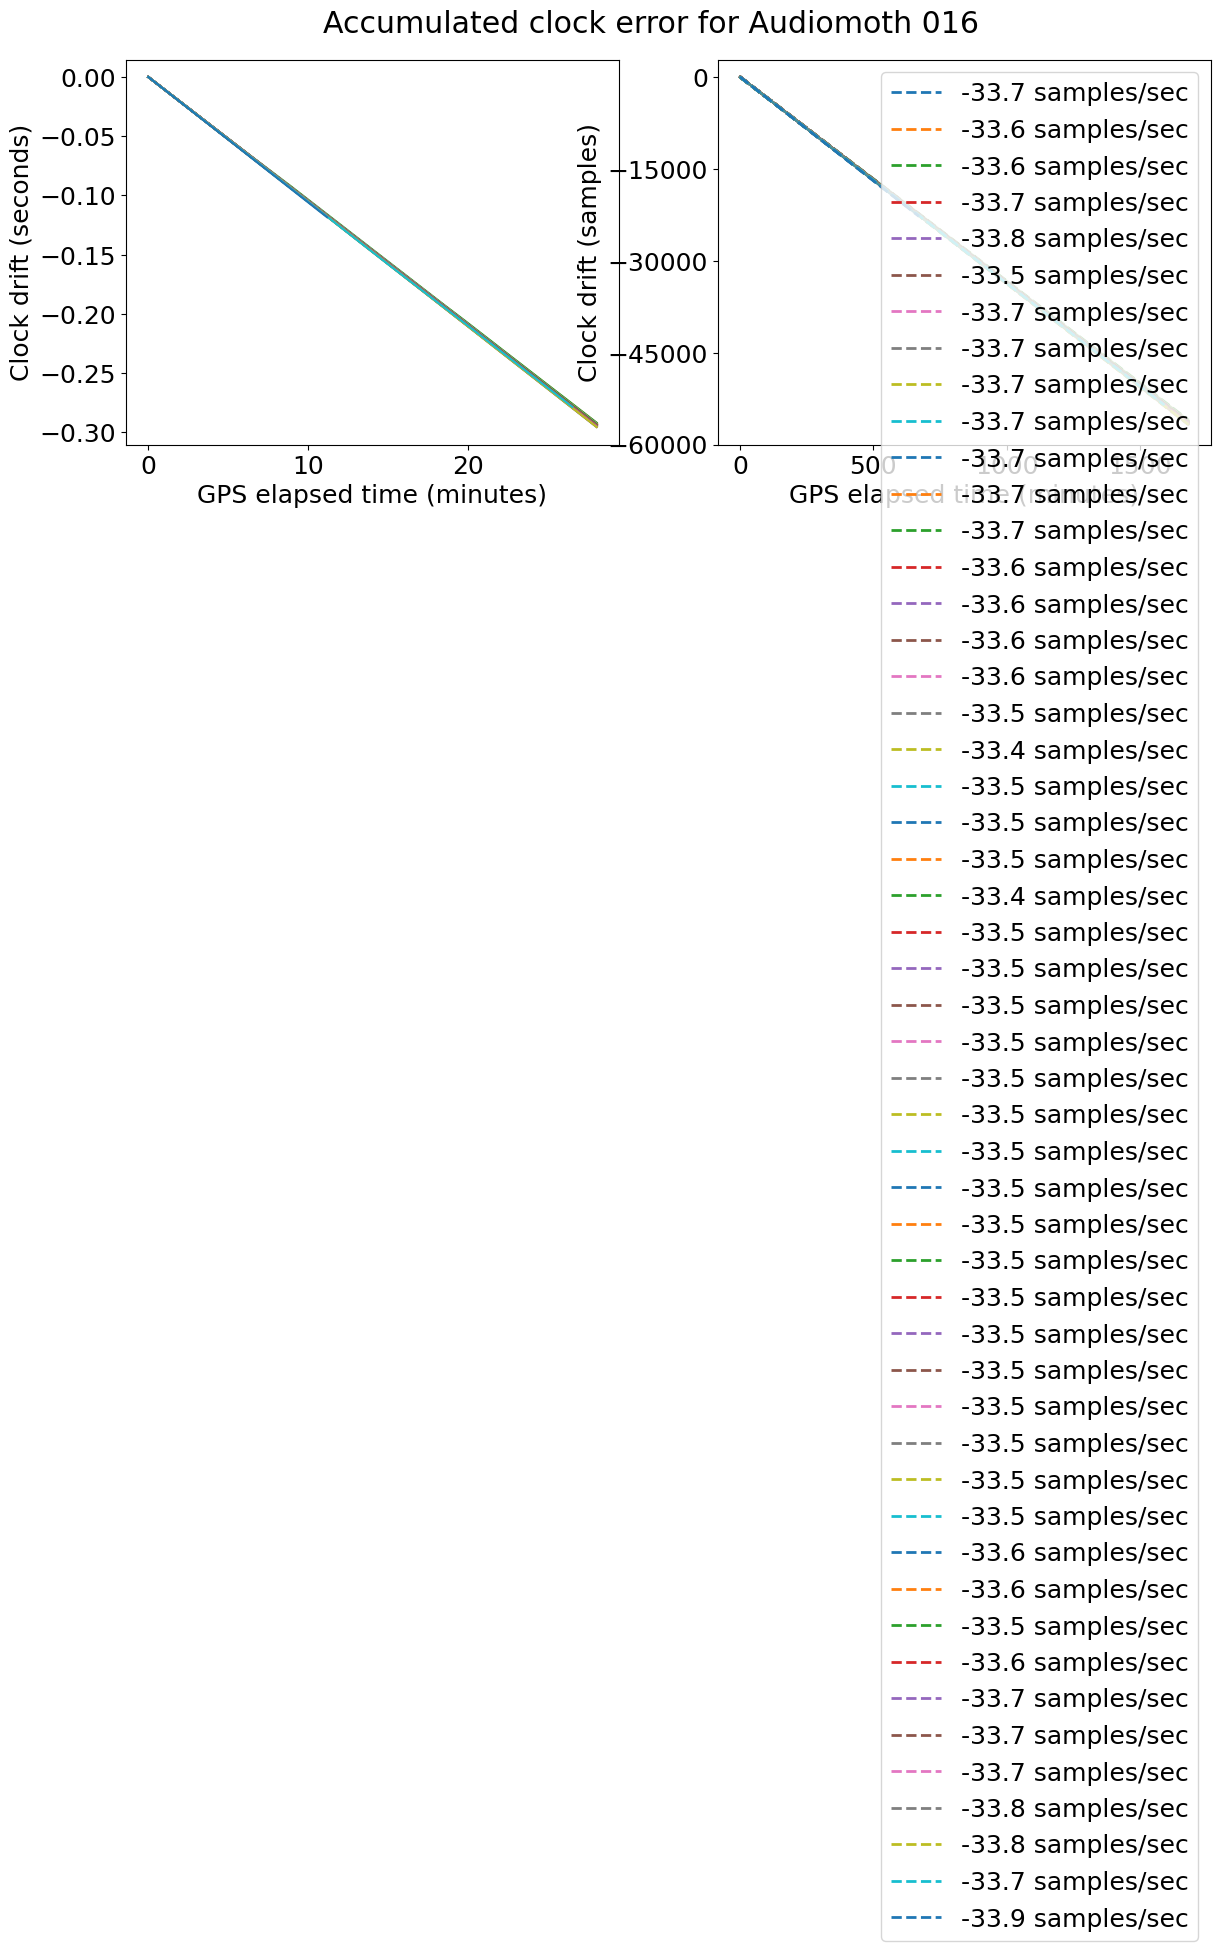

In [ ]:
clock_drift_rows = []
clock_drift_timeseries = {}

SD_CARD = 'STF_021'
for csv_file in sorted(valid_sync_csv_files["STF_021"]):
    csv_data = pd.read_csv(csv_file)

    valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
    csv_data = csv_data.loc[valid_rows].copy()

    csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"])
    csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

    # The first valid row represents the first one-second PPS interval.
    csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

    csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
    csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
    csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
    csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE

    gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
    final_clock_error_samples = csv_data["clock_error_samples"].iloc[-1]
    final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
    observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds

    clock_drift_rows.append({
        "file": csv_file.name,
        "gps_duration_seconds": gps_duration_seconds,
        "observed_sample_rate": observed_sample_rate,
        "final_clock_error_samples": final_clock_error_samples,
        "final_clock_error_seconds": final_clock_error_seconds
        })

    clock_drift_timeseries[csv_file.name] = csv_data

fig, ax_all = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams.update({'font.size': 18})

fig.suptitle(f"Accumulated clock error for Audiomoth {SD_CARD_TO_AUDIOMOTH_NUM[SD_CARD]}")

ax = ax_all[0]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = (csv_data["gps_elapsed_seconds"] / 60)
    ax.plot(elapsed_minutes, csv_data["clock_error_seconds"], label=file_name)

ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (seconds)")

ax = ax_all[1]
i = 0
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = csv_data["gps_elapsed_seconds"] / 60
    elapsed_secs = elapsed_minutes * 60
    clock_error_samples = csv_data["clock_error_samples"]

    valid_values = elapsed_secs.notna() & clock_error_samples.notna()
    regression_x = elapsed_secs.loc[valid_values].to_numpy()
    regression_y = clock_error_samples.loc[valid_values].to_numpy()

    slope, intercept = np.polyfit(regression_x, regression_y, deg=1)
    regression_y_predicted = slope * regression_x + intercept

    line, = ax.plot(regression_x, regression_y, alpha=0.5)
    if i < 1:
        ax.plot(
            regression_x,
            regression_y_predicted,
            linestyle="--",
            linewidth=2,
            color=line.get_color(),
            label=f"{slope:.1f} samples/sec",
        )
    i += 1

ax.set_yticks(np.arange(-60000, 100, 15000))
ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (samples)")
ax.legend(fontsize=18)

fig.tight_layout()
plt.show()

In [125]:
SD_CARD_TO_AUDIOMOTH_NUM.keys()

dict_keys(['STF_026', 'STF_028', 'STF_057', 'STF_109', 'STF_114', 'STF_053', 'STF_021', 'STF_116', 'STF_060', 'STF_025', 'STF_027', 'STF_113', 'STF_030'])

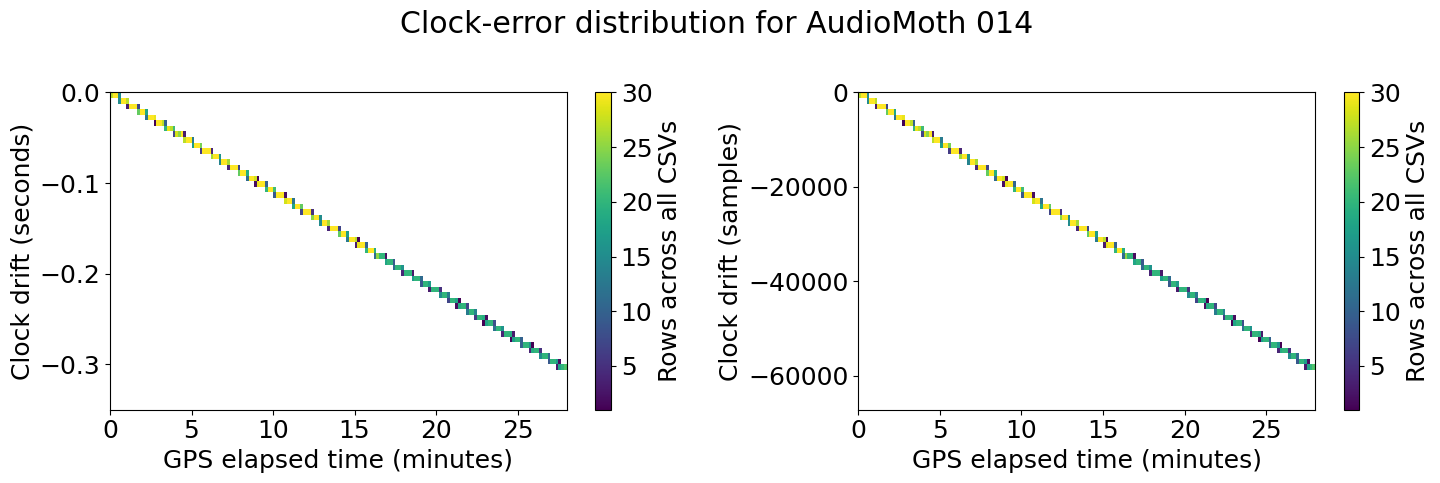

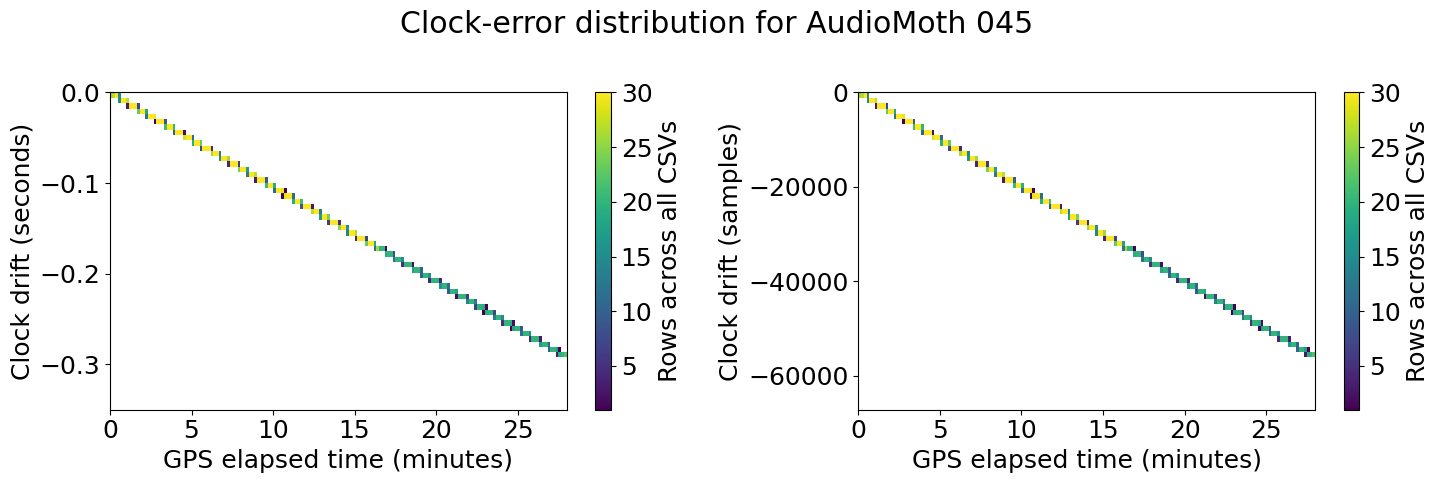

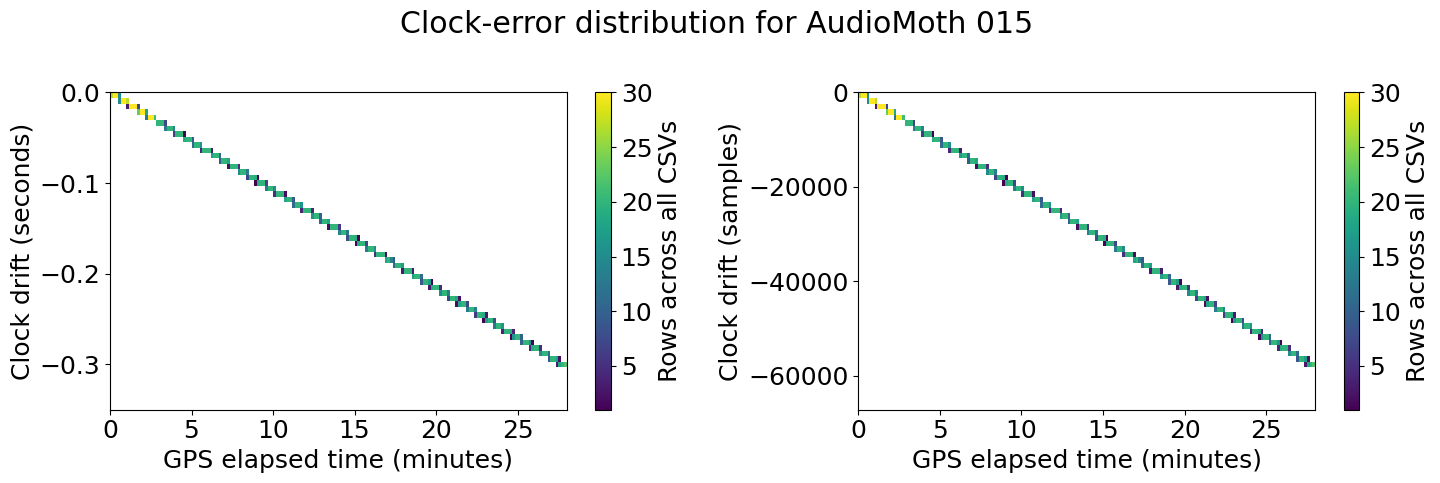

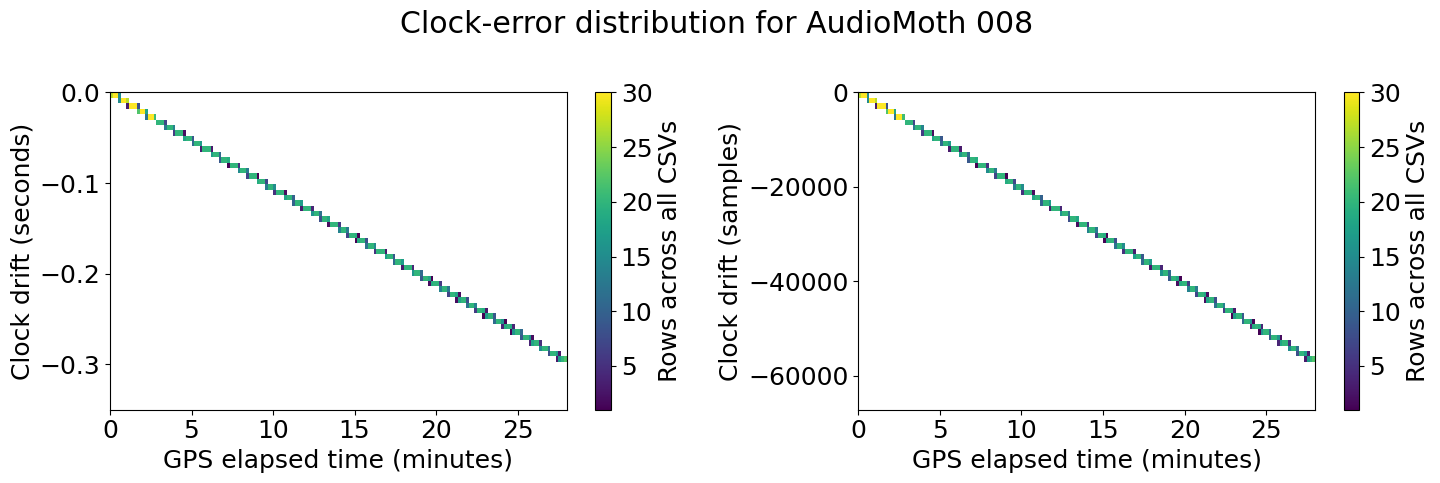

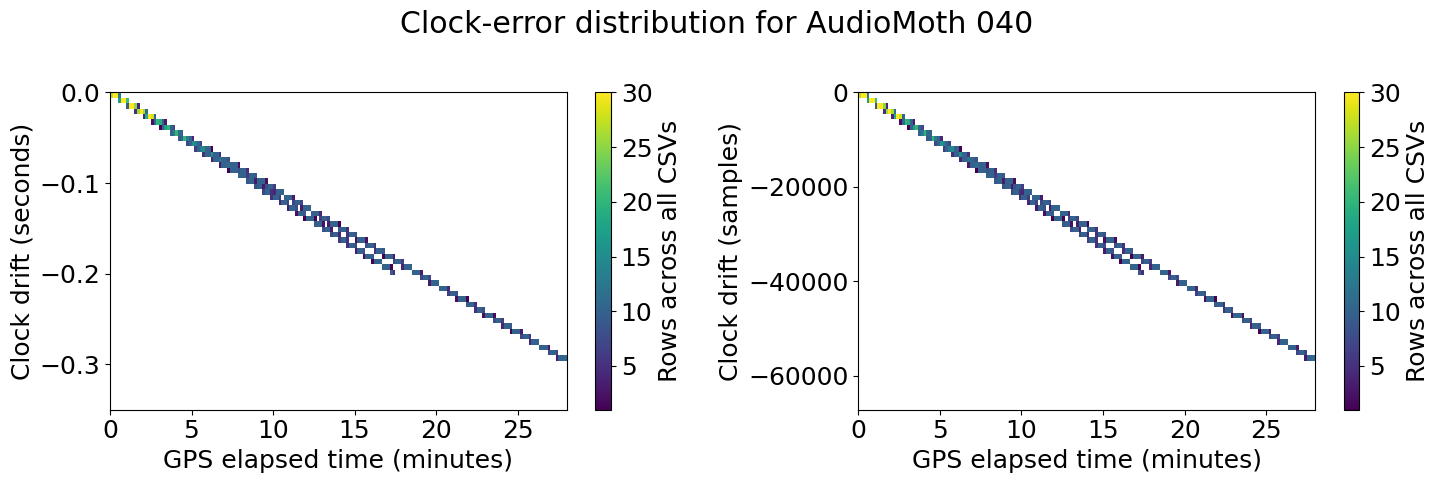

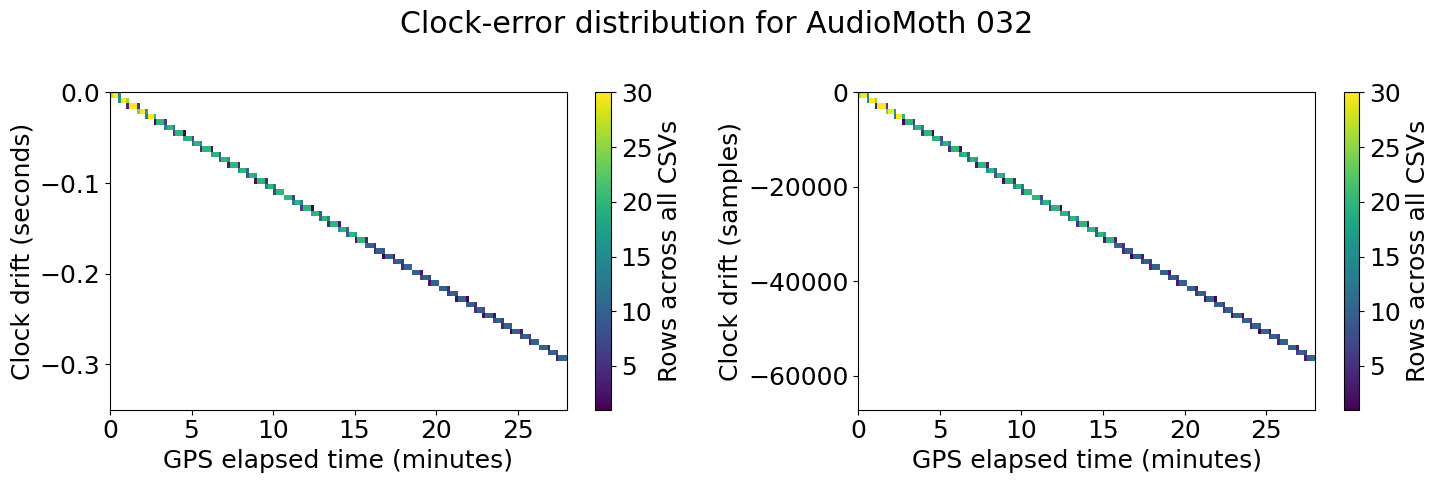

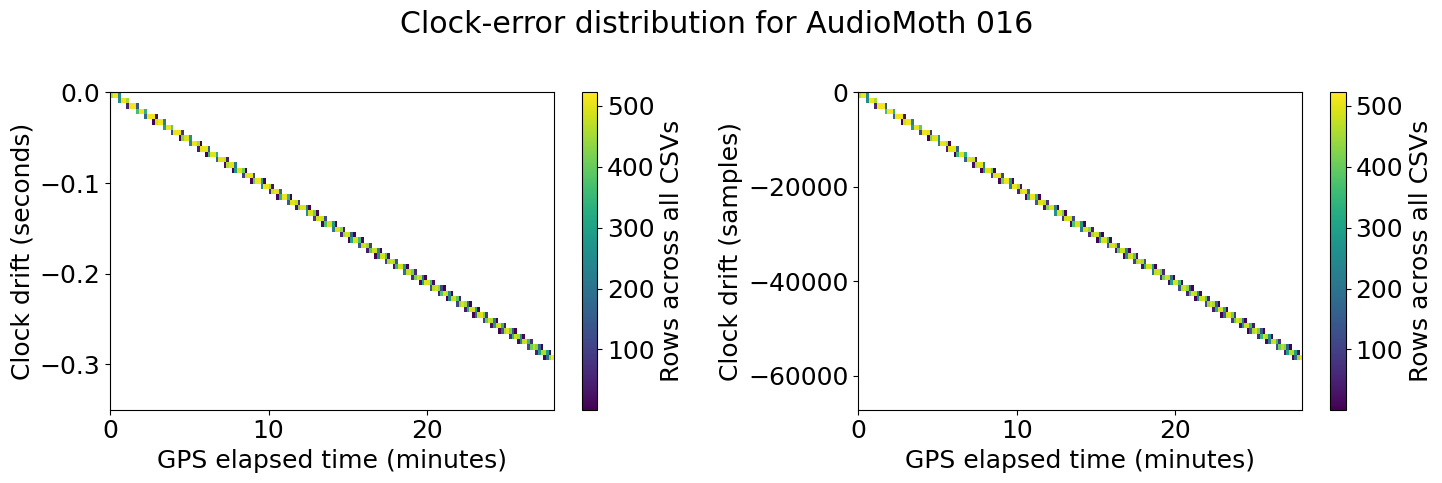

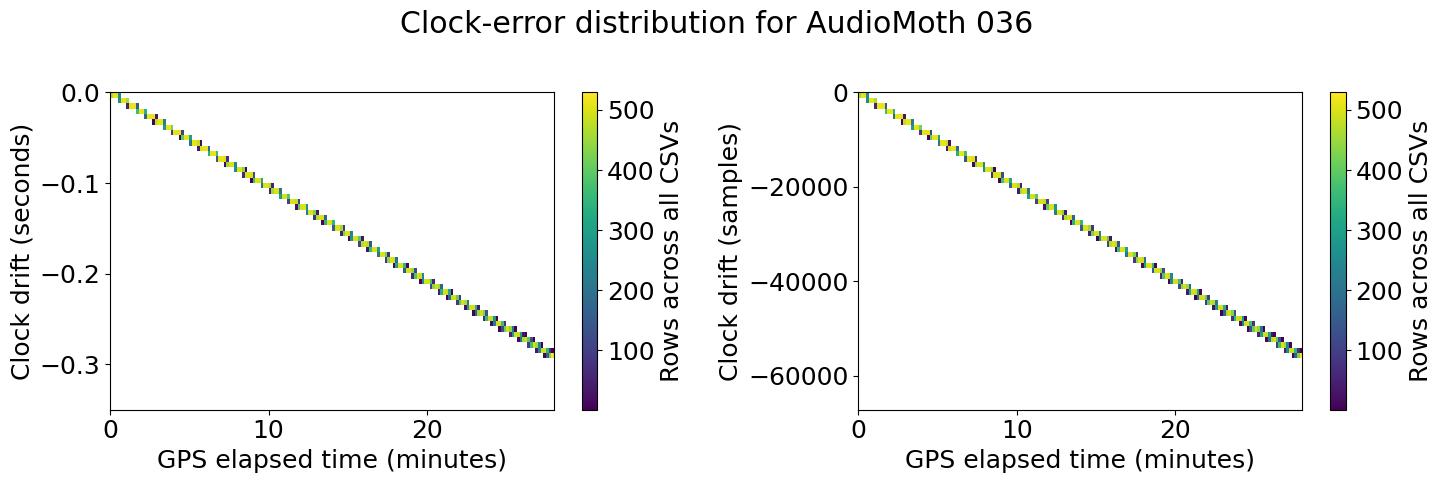

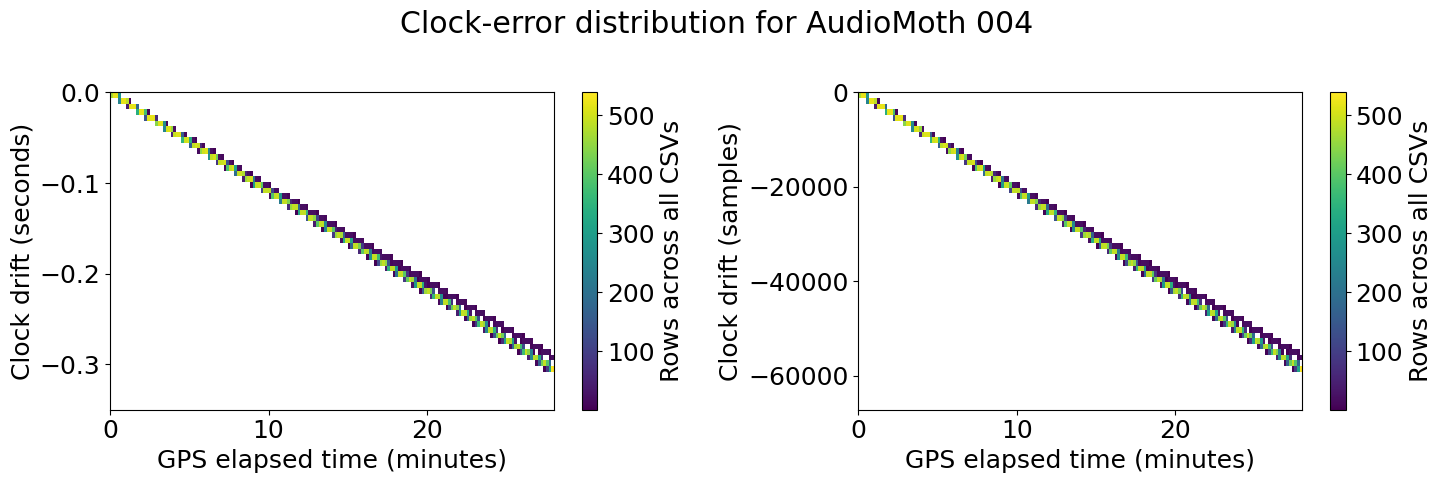

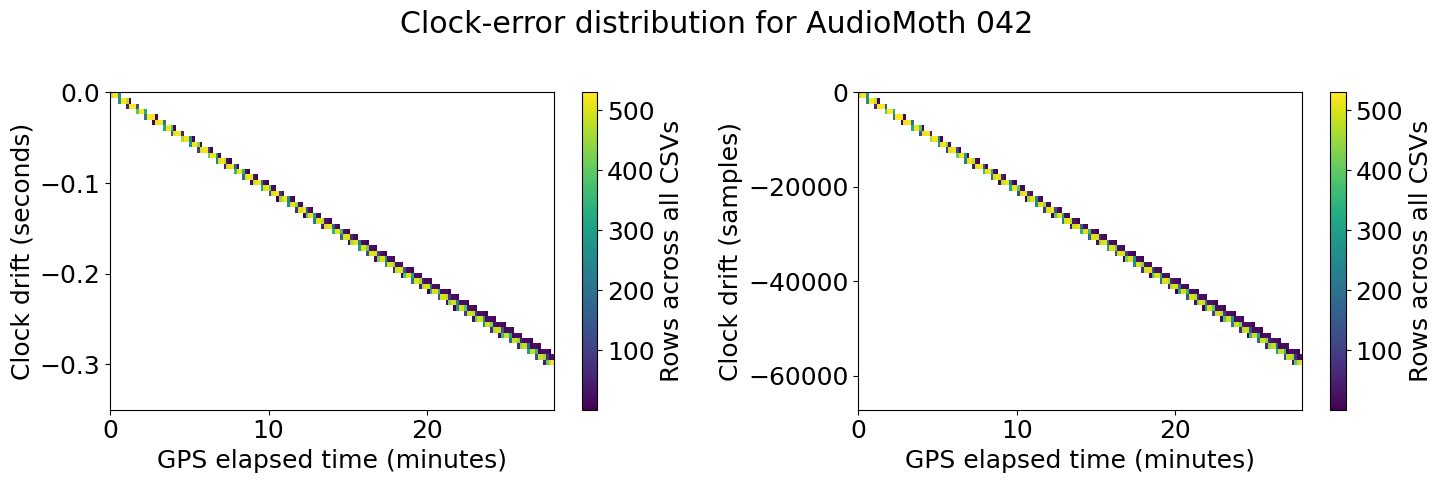

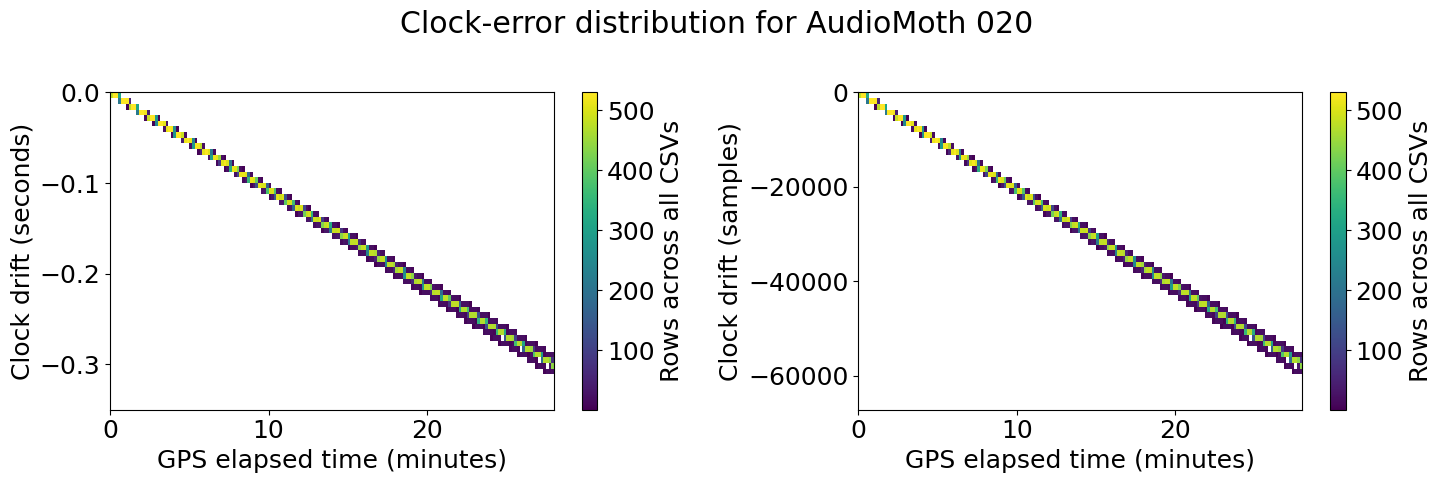

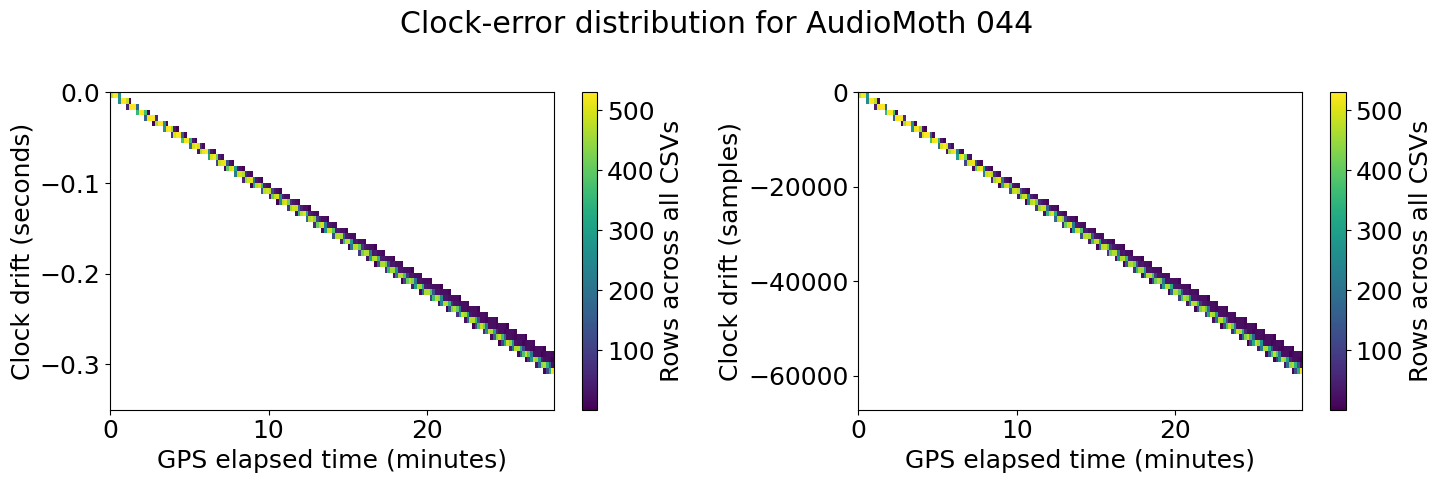

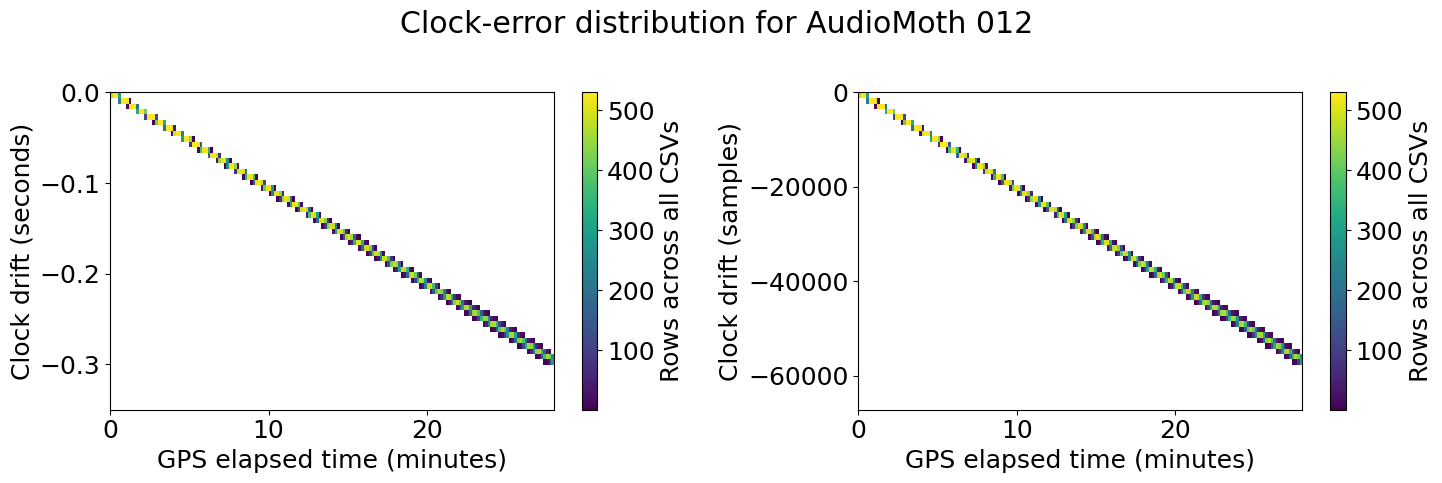

In [126]:
clock_drift_rows = []
clock_drift_timeseries = {}

for SD_CARD in SD_CARD_TO_AUDIOMOTH_NUM.keys():
    for csv_file in sorted(valid_sync_csv_files[SD_CARD]):
        csv_data = pd.read_csv(csv_file)

        valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
        csv_data = csv_data.loc[valid_rows].copy()

        csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"])
        csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

        # The first valid row represents the first one-second PPS interval.
        csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

        csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
        csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
        csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
        csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE

        gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
        final_clock_error_samples = csv_data["clock_error_samples"].iloc[-1]
        final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
        observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds

        clock_drift_rows.append({
            "file": csv_file.name,
            "gps_duration_seconds": gps_duration_seconds,
            "observed_sample_rate": observed_sample_rate,
            "final_clock_error_samples": final_clock_error_samples,
            "final_clock_error_seconds": final_clock_error_seconds
            })

        clock_drift_timeseries[csv_file.name] = csv_data

    clock_drift_data = pd.concat(clock_drift_timeseries.values(), ignore_index=True)

    GPS_BIN_SECONDS = 10
    DRIFT_BINS = 50

    maximum_elapsed_seconds = int(np.ceil(clock_drift_data["gps_elapsed_seconds"].max()))
    gps_bin_edges_seconds = np.arange(0, maximum_elapsed_seconds + GPS_BIN_SECONDS, GPS_BIN_SECONDS)
    gps_bin_edges_minutes = gps_bin_edges_seconds / 60

    fig, ax_all = plt.subplots(1, 2, figsize=(15, 5))
    plt.rcParams.update({"font.size": 18})

    fig.suptitle(f"Clock-error distribution for AudioMoth {SD_CARD_TO_AUDIOMOTH_NUM[SD_CARD]}")

    ax = ax_all[0]
    hist_seconds = ax.hist2d(
        clock_drift_data["gps_elapsed_seconds"] / 60,
        clock_drift_data["clock_error_seconds"],
        bins=[gps_bin_edges_minutes, DRIFT_BINS],
        cmap="viridis",
        cmin=1,
    )

    ax.set_ylim(-0.35, 0)
    ax.set_xlabel("GPS elapsed time (minutes)")
    ax.set_ylabel("Clock drift (seconds)")
    fig.colorbar(hist_seconds[3], ax=ax, label="Rows across all CSVs")

    ax = ax_all[1]
    hist_samples = ax.hist2d(
        clock_drift_data["gps_elapsed_seconds"] / 60,
        clock_drift_data["clock_error_samples"],
        bins=[gps_bin_edges_minutes, DRIFT_BINS],
        cmap="viridis",
        cmin=1,
    )

    ax.set_ylim(-0.35 * NOMINAL_SAMPLE_RATE, 0)
    ax.set_xlabel("GPS elapsed time (minutes)")
    ax.set_ylabel("Clock drift (samples)")
    fig.colorbar(hist_samples[3], ax=ax, label="Rows across all CSVs")

    fig.tight_layout()
    plt.show()

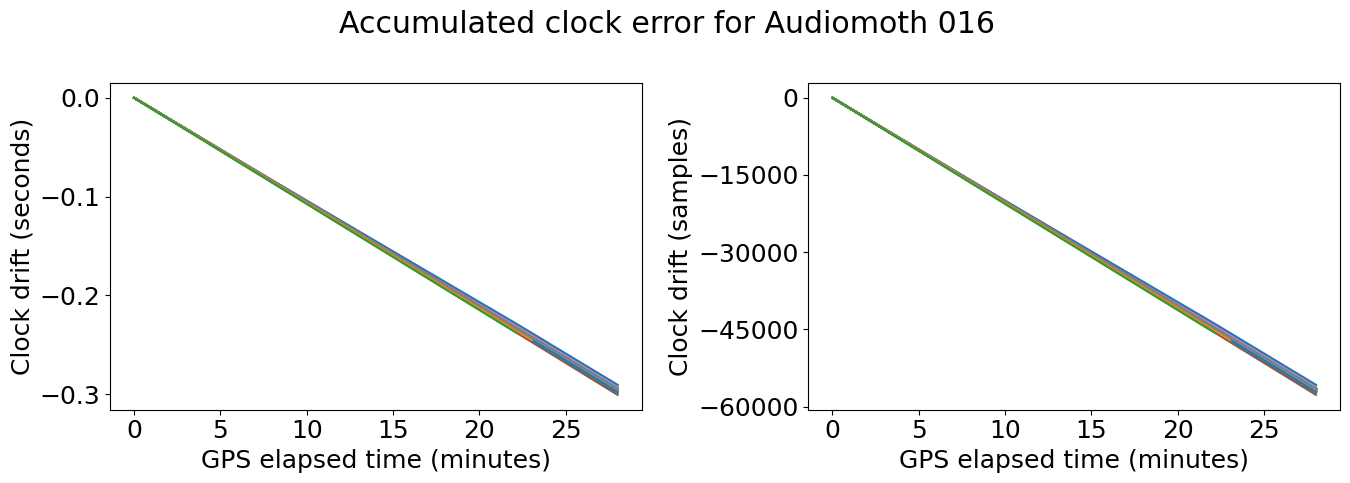

In [127]:
fig, ax_all = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams.update({'font.size': 18})

fig.suptitle("Accumulated clock error for Audiomoth 016")

ax = ax_all[0]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = (csv_data["gps_elapsed_seconds"] / 60)
    ax.plot(elapsed_minutes, csv_data["clock_error_seconds"], label=file_name)

ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (seconds)")

ax = ax_all[1]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = (csv_data["gps_elapsed_seconds"] / 60)
    ax.plot(elapsed_minutes, csv_data["clock_error_samples"], label=file_name)

ax.set_yticks(np.arange(-60000, 100, 15000))
ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (samples)")

fig.tight_layout()
plt.show()

In [128]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260610'
all_wav_files = list(experiment_folder.glob('STF_*/2026*0.WAV'))
all_sync_wav_files = list(experiment_folder.glob('STF_*/2026*_SYNC.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*0.CSV'))
all_wav_files, all_sync_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260605_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260605_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260605_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260605_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260606_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260606_213000.WAV'),


In [129]:
REPLACED_SD_CARD_TO_AUDIOMOTH_NUM = {
    "STF_036": "014",
    "STF_074": "045",
    "STF_035": "015",
    "STF_039": "008",
    "STF_070": "040",
    "STF_064": "032",
    "STF_065": "016",
    "STF_066": "036",
    "STF_068": "004",
    "STF_079": "042",
    "STF_073": "020",
    "STF_040": "044",
    "STF_037": "012",
}

In [130]:
valid_sync_csv_files = dict.fromkeys(REPLACED_SD_CARD_TO_AUDIOMOTH_NUM, [])
for csv_file in all_csv_files:
    csv_file_dt = dt.datetime.strptime(csv_file.name, '%Y%m%d_%H%M%S.CSV')
    sd_card_name = csv_file.parts[-2]
    valid_sync_csv_files[sd_card_name] += [csv_file]
valid_sync_csv_files

{'STF_036': [PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_200000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_203000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_210000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_213000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_220000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_223000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_230000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260604_233000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260605_000000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_039/20260605_003

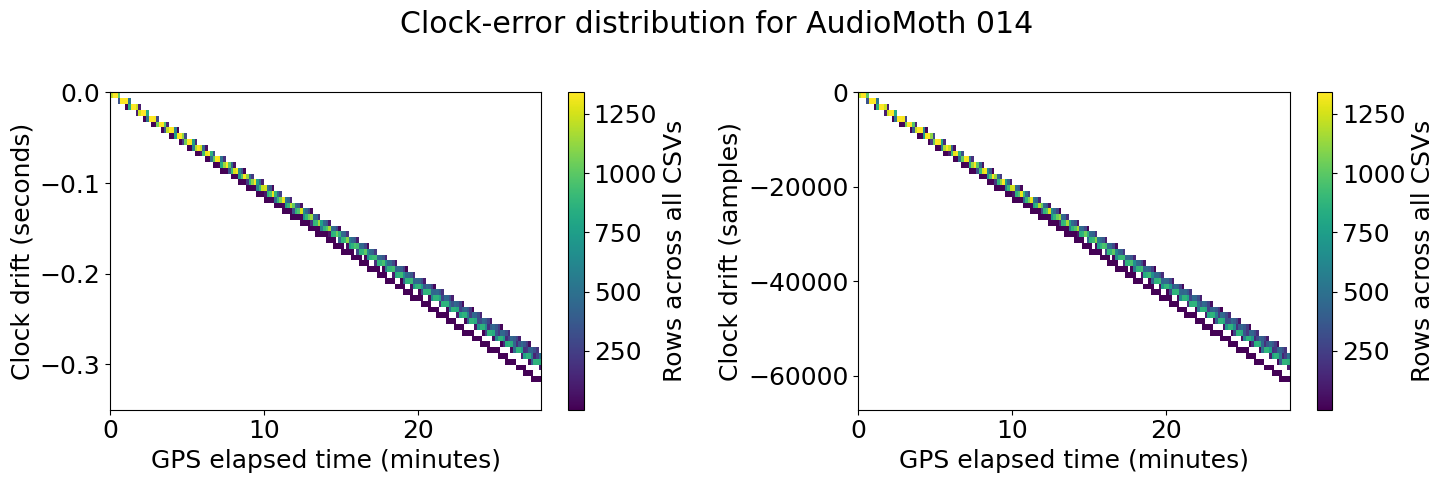

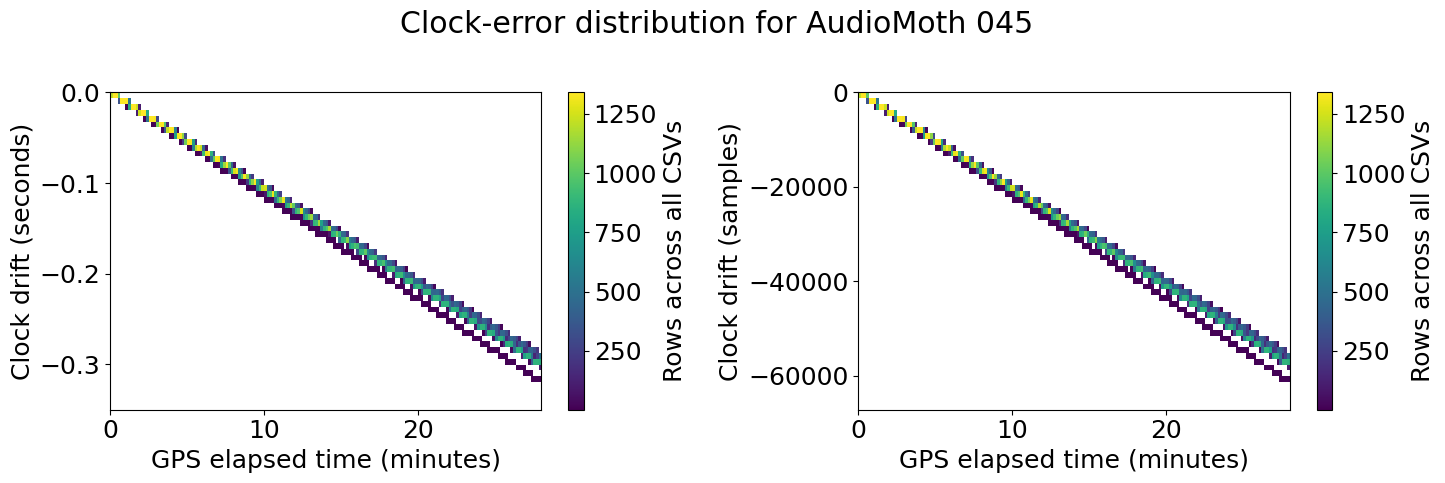

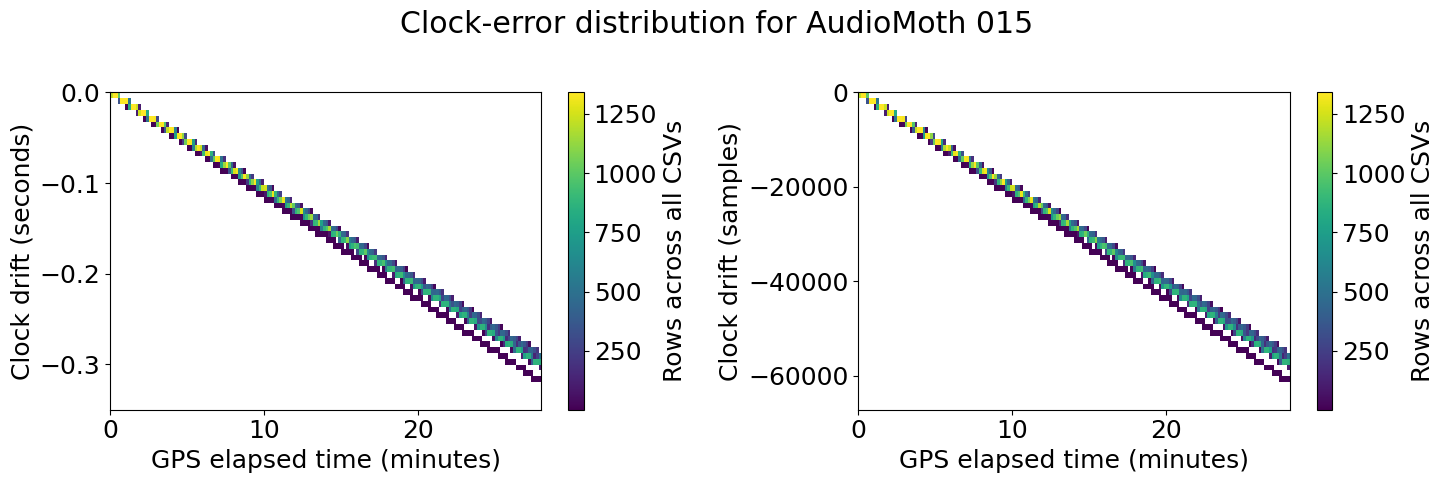

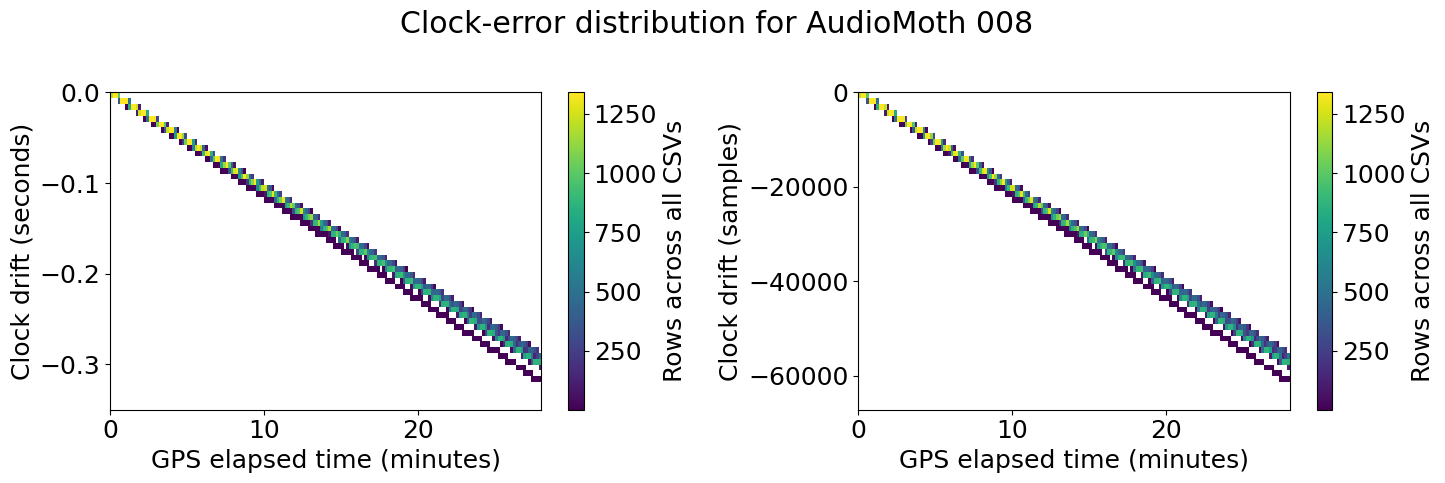

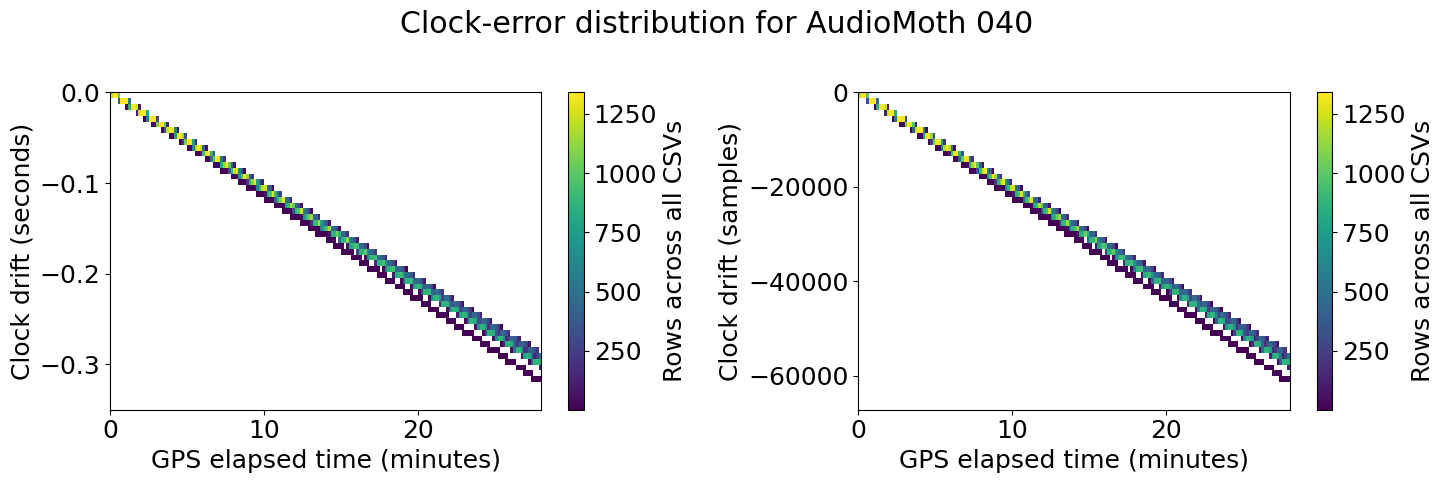

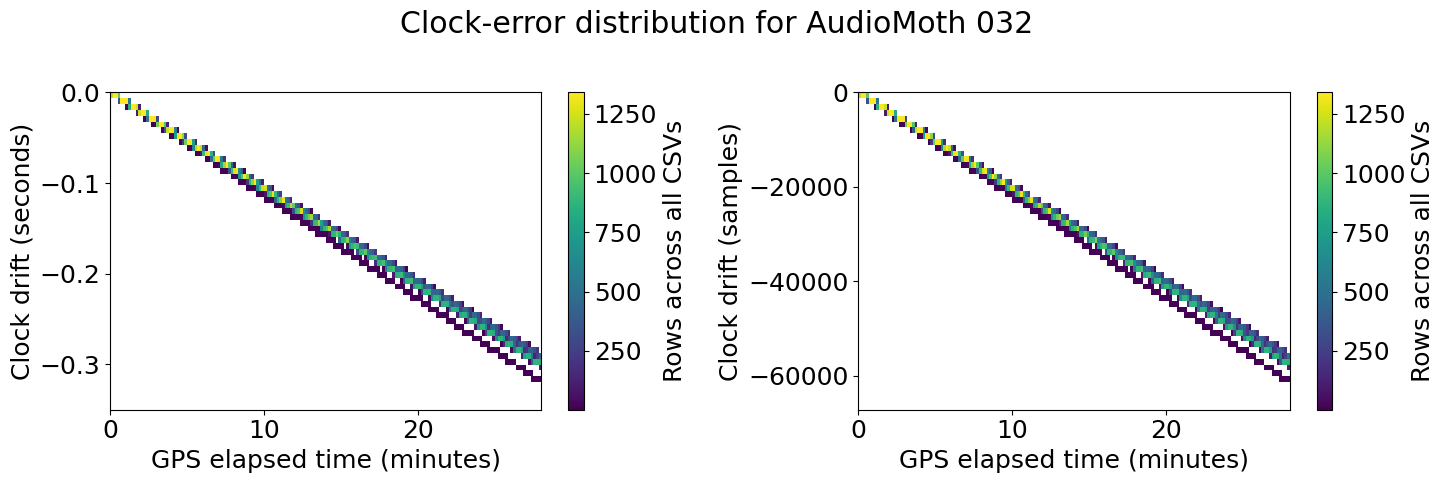

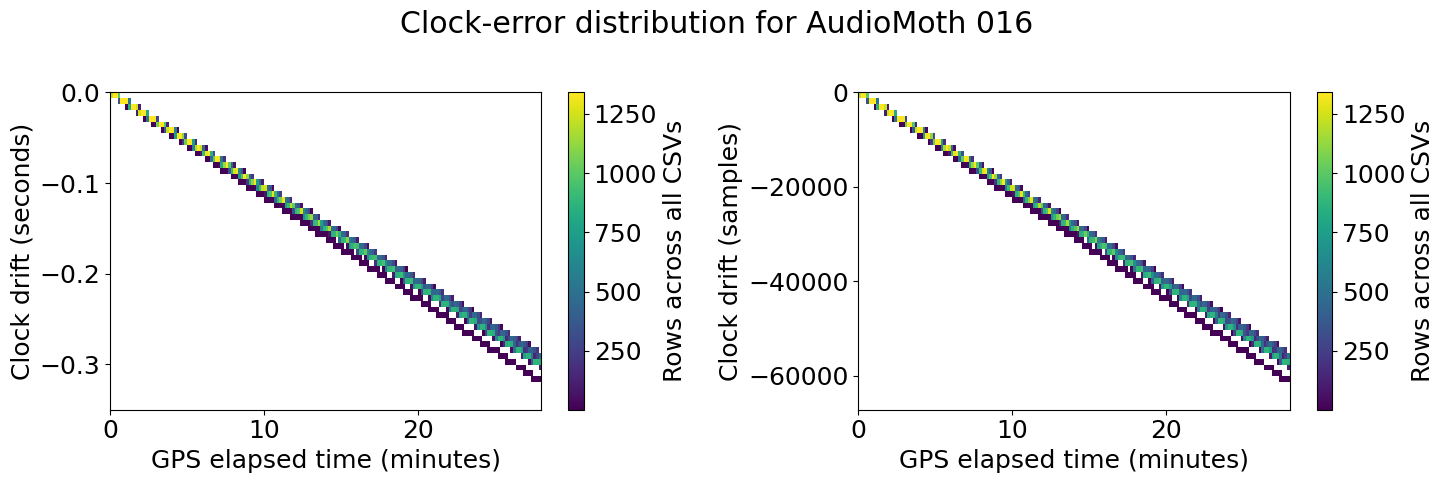

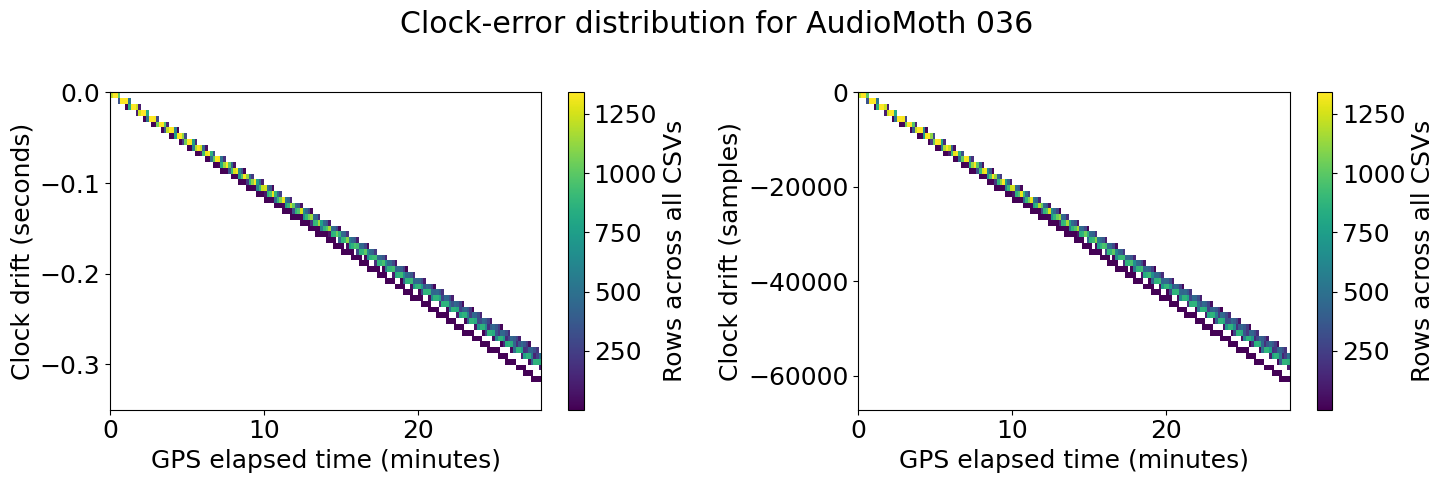

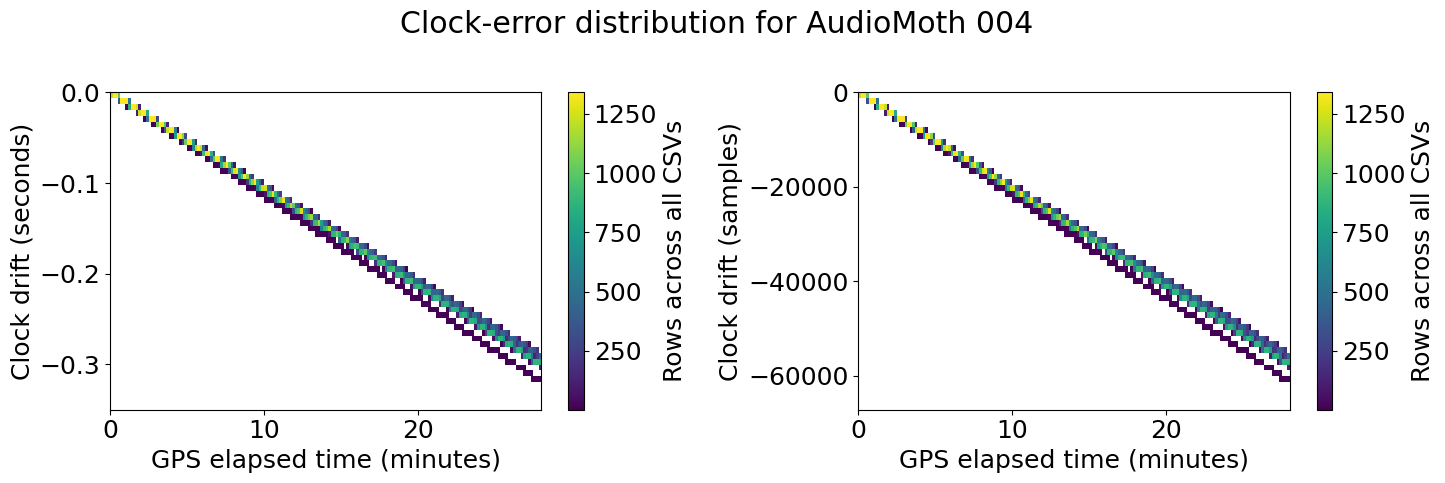

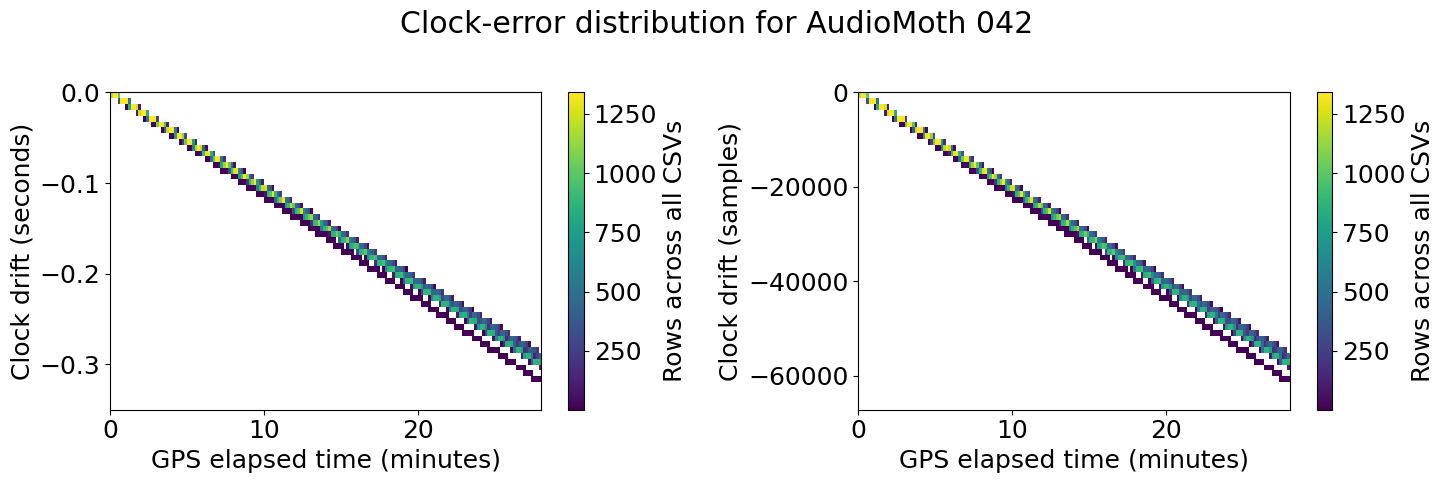

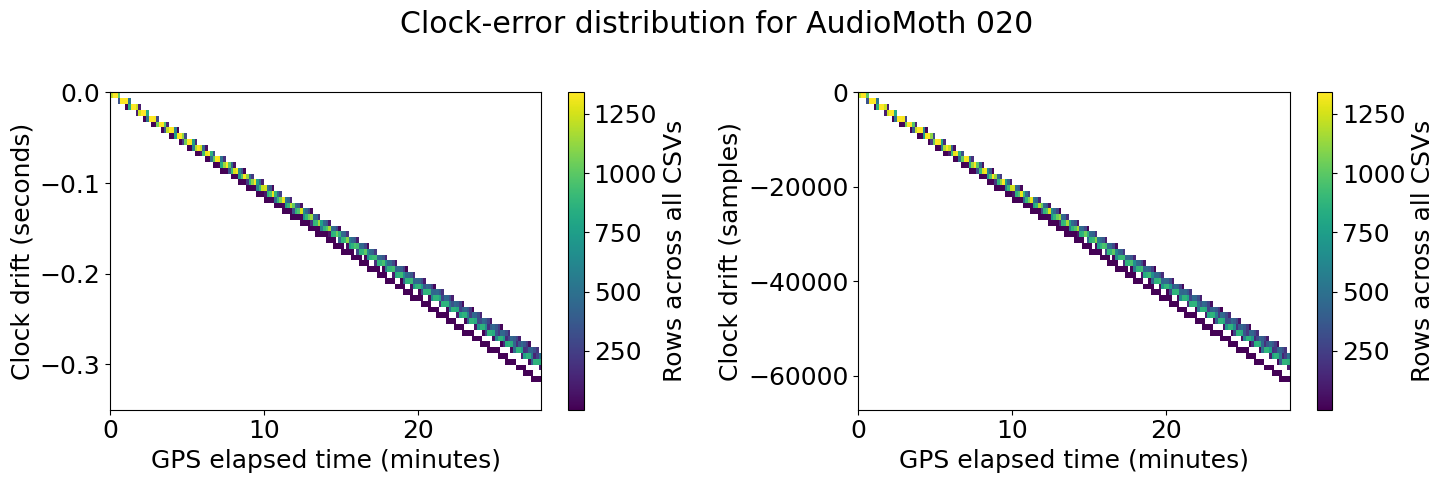

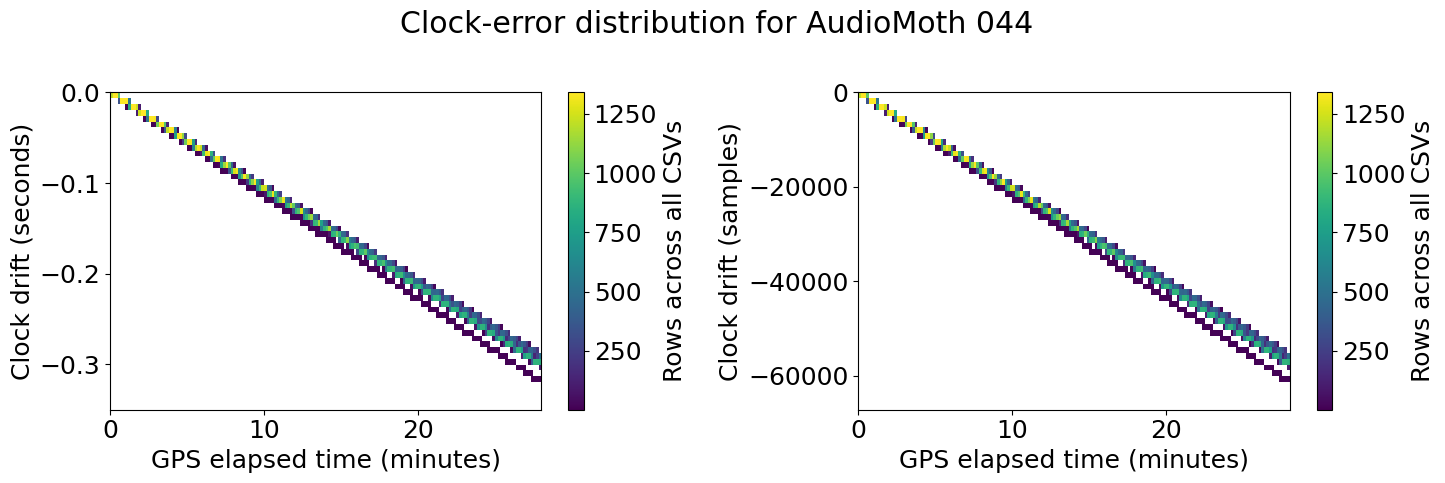

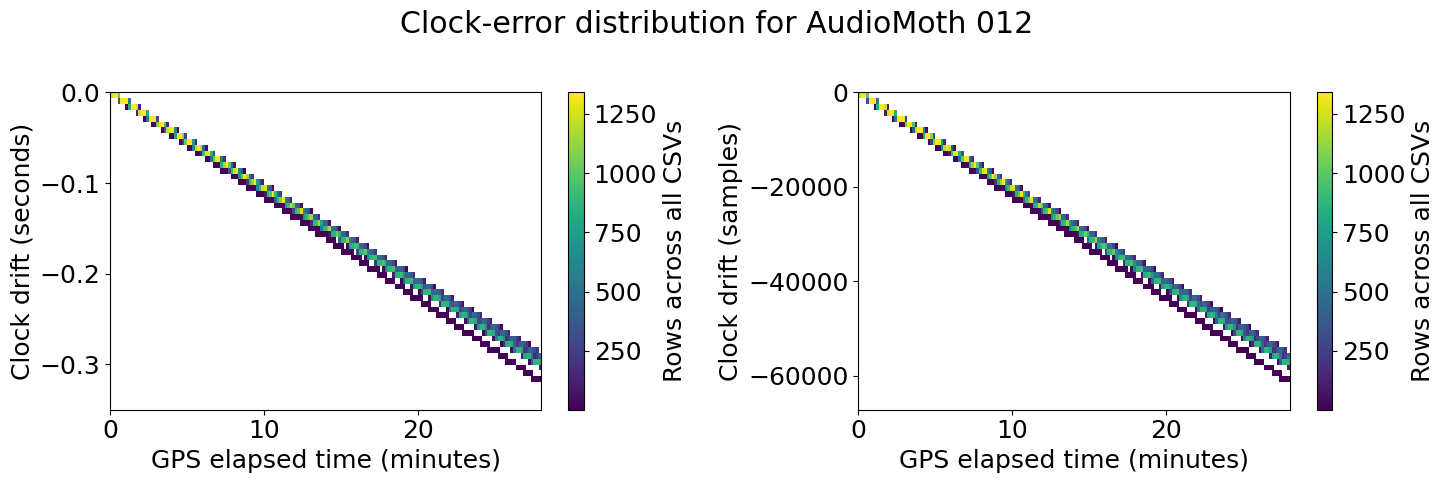

In [131]:
clock_drift_rows = []
clock_drift_timeseries = {}

for SD_CARD in REPLACED_SD_CARD_TO_AUDIOMOTH_NUM.keys():
    for csv_file in sorted(valid_sync_csv_files[SD_CARD]):
        csv_data = pd.read_csv(csv_file, on_bad_lines="skip")

        valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
        csv_data = csv_data.loc[valid_rows].copy()

        csv_data["LAST_RMC_GPS_TIME"] = csv_data["LAST_RMC_GPS_TIME"].str[:23]
        csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"], format="%Y-%m-%dT%H:%M:%S.%f")
        csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

        # The first valid row represents the first one-second PPS interval.
        csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

        csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
        csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
        csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
        csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE

        gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
        final_clock_error_samples = csv_data["clock_error_samples"].iloc[-1]
        final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
        observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds

        clock_drift_rows.append({
            "file": csv_file.name,
            "gps_duration_seconds": gps_duration_seconds,
            "observed_sample_rate": observed_sample_rate,
            "final_clock_error_samples": final_clock_error_samples,
            "final_clock_error_seconds": final_clock_error_seconds
            })

        clock_drift_timeseries[csv_file.name] = csv_data

    clock_drift_data = pd.concat(clock_drift_timeseries.values(), ignore_index=True)

    GPS_BIN_SECONDS = 10
    DRIFT_BINS = 50

    maximum_elapsed_seconds = int(np.ceil(clock_drift_data["gps_elapsed_seconds"].max()))
    gps_bin_edges_seconds = np.arange(0, maximum_elapsed_seconds + GPS_BIN_SECONDS, GPS_BIN_SECONDS)
    gps_bin_edges_minutes = gps_bin_edges_seconds / 60

    fig, ax_all = plt.subplots(1, 2, figsize=(15, 5))
    plt.rcParams.update({"font.size": 18})

    fig.suptitle(f"Clock-error distribution for AudioMoth {REPLACED_SD_CARD_TO_AUDIOMOTH_NUM[SD_CARD]}")

    ax = ax_all[0]
    hist_seconds = ax.hist2d(
        clock_drift_data["gps_elapsed_seconds"] / 60,
        clock_drift_data["clock_error_seconds"],
        bins=[gps_bin_edges_minutes, DRIFT_BINS],
        cmap="viridis",
        cmin=1,
    )

    ax.set_ylim(-0.35, 0)
    ax.set_xlabel("GPS elapsed time (minutes)")
    ax.set_ylabel("Clock drift (seconds)")
    fig.colorbar(hist_seconds[3], ax=ax, label="Rows across all CSVs")

    ax = ax_all[1]
    hist_samples = ax.hist2d(
        clock_drift_data["gps_elapsed_seconds"] / 60,
        clock_drift_data["clock_error_samples"],
        bins=[gps_bin_edges_minutes, DRIFT_BINS],
        cmap="viridis",
        cmin=1,
    )

    ax.set_ylim(-0.35 * NOMINAL_SAMPLE_RATE, 0)
    ax.set_xlabel("GPS elapsed time (minutes)")
    ax.set_ylabel("Clock drift (samples)")
    fig.colorbar(hist_samples[3], ax=ax, label="Rows across all CSVs")

    fig.tight_layout()
    plt.show()

In [132]:
REPLACED_SD_CARD_TO_AUDIOMOTH_NUM

{'STF_036': '014',
 'STF_074': '045',
 'STF_035': '015',
 'STF_039': '008',
 'STF_070': '040',
 'STF_064': '032',
 'STF_065': '016',
 'STF_066': '036',
 'STF_068': '004',
 'STF_079': '042',
 'STF_073': '020',
 'STF_040': '044',
 'STF_037': '012'}

/var/folders/qj/4txkrxcn2ld7mby9_6n6npnr0000gn/T/ipykernel_70452/1922696328.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


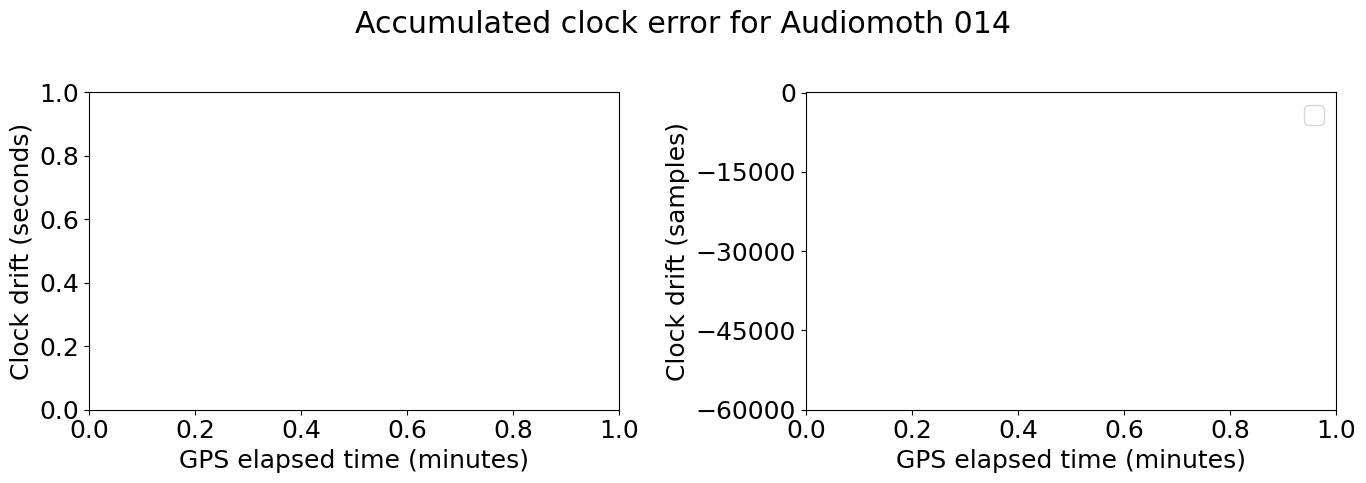

In [133]:
clock_drift_rows = []
clock_drift_timeseries = {}

SD_CARD = 'STF_036'
for csv_file in sorted(valid_sync_csv_files[SD_CARD]):
    csv_data = pd.read_csv(csv_file, on_bad_lines="skip")

    valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
    csv_data = csv_data.loc[valid_rows].copy()

    csv_data["LAST_RMC_GPS_TIME"] = csv_data["LAST_RMC_GPS_TIME"].str[:23]
    csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"], format="%Y-%m-%dT%H:%M:%S.%f")
    csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

    # The first valid row represents the first one-second PPS interval.
    csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

    csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
    csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
    csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
    csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE

    gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
    final_clock_error_samples = csv_data["clock_error_samples"].iloc[-1]
    final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
    observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds

    clock_drift_rows.append({
        "file": csv_file.name,
        "gps_duration_seconds": gps_duration_seconds,
        "observed_sample_rate": observed_sample_rate,
        "final_clock_error_samples": final_clock_error_samples,
        "final_clock_error_seconds": final_clock_error_seconds
        })

    clock_drift_timeseries[csv_file.name] = csv_data

fig, ax_all = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams.update({'font.size': 18})

fig.suptitle(f"Accumulated clock error for Audiomoth {REPLACED_SD_CARD_TO_AUDIOMOTH_NUM[SD_CARD]}")

ax = ax_all[0]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = (csv_data["gps_elapsed_seconds"] / 60)
    if csv_data["clock_error_seconds"].iloc[0] > 1:
        ax.plot(elapsed_minutes, csv_data["clock_error_seconds"], label=file_name)

ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (seconds)")

ax = ax_all[1]
for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = (csv_data["gps_elapsed_seconds"] / 60)
    if csv_data["clock_error_seconds"].iloc[0] > 1:
        ax.plot(elapsed_minutes, csv_data["clock_error_samples"], label=file_name)

ax.set_yticks(np.arange(-60000, 100, 15000))
ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Clock drift (samples)")
ax.legend()

fig.tight_layout()
plt.show()

In [101]:
csv_file

PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260610/STF_066/20260606_053000.CSV')

In [98]:
pd.read_csv(csv_file)

ParserError: Error tokenizing data. C error: Expected 16 fields in line 411, saw 18


In [47]:
recording_start_rows = []

for csv_file in sorted(valid_sync_csv_files["STF_021"]):
    csv_data = pd.read_csv(csv_file)

    scheduled_start = pd.to_datetime(csv_file.stem, format="%Y%m%d_%H%M%S")
    raw_recording_start = pd.to_datetime(csv_data["AUDIOMOTH_TIME"].iloc[0])
    start_error_seconds = (raw_recording_start - scheduled_start).total_seconds()

    recording_start_rows.append({
        "file": csv_file.name,
        "scheduled_start": scheduled_start,
        "raw_recording_start": raw_recording_start,
        "start_error_seconds": start_error_seconds
    })

recording_start_summary = pd.DataFrame(recording_start_rows)
recording_start_summary

,file,scheduled_start,raw_recording_start,start_error_seconds
0,20260603_193756.CSV,2026-06-03 19:37:56,2026-06-03 19:37:56.000,0.000
1,20260603_200000.CSV,2026-06-03 20:00:00,2026-06-03 19:59:59.999,-0.001
2,20260603_203000.CSV,2026-06-03 20:30:00,2026-06-03 20:29:59.999,-0.001
3,20260603_210000.CSV,2026-06-03 21:00:00,2026-06-03 20:59:59.999,-0.001
4,20260603_213000.CSV,2026-06-03 21:30:00,2026-06-03 21:29:59.999,-0.001
5,20260603_220000.CSV,2026-06-03 22:00:00,2026-06-03 21:59:59.999,-0.001
6,20260603_223000.CSV,2026-06-03 22:30:00,2026-06-03 22:29:59.999,-0.001
7,20260603_230000.CSV,2026-06-03 23:00:00,2026-06-03 22:59:59.999,-0.001
8,20260603_233000.CSV,2026-06-03 23:30:00,2026-06-03 23:29:59.999,-0.001
9,20260604_000000.CSV,2026-06-04 00:00:00,2026-06-03 23:59:59.999,-0.001
